In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

In [2]:
DATA_DIR = Path("../../results/processed_hrv")

INPUT_FILE = DATA_DIR / "basal_v2_clean.csv"

FIG_DIR = Path("../../results/eda_categorical_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path("../../results/eda_categorical_tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(INPUT_FILE)

print(df.shape)
df.head()

(530, 26)


,sex,age,weight_kg,height_cm_final,height_m_final,imc_final,bp_systolic,bp_diastolic,bp_pam,bp_pp,...,t2m_pre_hf,t2m_pre_lf,t2m_pre_vlf,mean_hr_from_rr,height_inconsistent,imc_inconsistent,hr_rr_inconsistent,n_integrity_flags,n_range_flags,n_total_qc_flags
0,1,75,70.0,160.0,1.60,27.343750,108,70,82.666667,38,...,222,713,172,80.213904,False,False,False,0,0,0
1,1,66,52.0,149.0,1.49,23.422368,122,72,88.666667,50,...,87,226,29,62.959077,False,False,False,0,0,0
2,2,77,81.0,170.0,1.70,28.027682,125,85,98.333333,40,...,26,137,9,68.415051,False,False,False,0,0,0
3,1,77,85.0,160.0,1.60,33.203125,126,72,90.000000,54,...,118,130,14,73.260073,False,False,False,0,0,0
4,1,73,69.0,151.0,1.51,30.261831,130,80,96.666667,50,...,66,66,18,70.921986,False,False,False,0,0,0


In [4]:
hrv_cols = [
    "t2m_pre_mean_rr",
    "t2m_pre_mean_hr",
    "t2m_pre_sdnn",
    "t2m_pre_rmssd",
    "t2m_pre_hf",
    "t2m_pre_lf",
    "t2m_pre_vlf",
]

phys_cols = [
    "sex",
    "age",
    "imc_final",
    "bp_systolic",
    "bp_diastolic",
    "bp_pam",
    "bp_pp",
]

In [5]:
def age_group(x):
    
    if pd.isna(x):
        return np.nan
    
    if x < 60:
        return "<60"
    elif x < 70:
        return "60-69"
    elif x < 80:
        return "70-79"
    else:
        return "80+"

df["age_group"] = df["age"].apply(age_group)

df["age_group"].value_counts()

age_group
70-79    261
60-69    219
80+       40
<60       10
Name: count, dtype: int64

In [6]:
def bmi_cat_chile_older(x):
    
    if pd.isna(x):
        return np.nan
    
    if x < 23:
        return "low"
    elif x < 28:
        return "normal"
    elif x < 32:
        return "overweight"
    else:
        return "obesity"

df["bmi_cat"] = df["imc_final"].apply(bmi_cat_chile_older)

df["bmi_cat"].value_counts()

bmi_cat
obesity       184
overweight    162
normal        161
low            23
Name: count, dtype: int64

In [7]:
def bp_cat(row):
    
    sbp = row["bp_systolic"]
    dbp = row["bp_diastolic"]
    
    if pd.isna(sbp) or pd.isna(dbp):
        return np.nan
    
    if sbp < 140 and dbp < 90:
        return "normal"
    else:
        return "high"

df["bp_cat"] = df.apply(bp_cat, axis=1)

df["bp_cat"].value_counts()

bp_cat
normal    369
high      161
Name: count, dtype: int64

In [8]:
pd.crosstab(df["sex"], df["age_group"])

age_group,60-69,70-79,80+,<60
sex,,,,
1,162,167,29,8
2,57,94,11,2


In [9]:
pd.crosstab(df["sex"], df["bmi_cat"])

bmi_cat,low,normal,obesity,overweight
sex,,,,
1,17,114,130,105
2,6,47,54,57


In [10]:
pd.crosstab(df["sex"], df["bp_cat"])

bp_cat,high,normal
sex,,
1,105,261
2,56,108


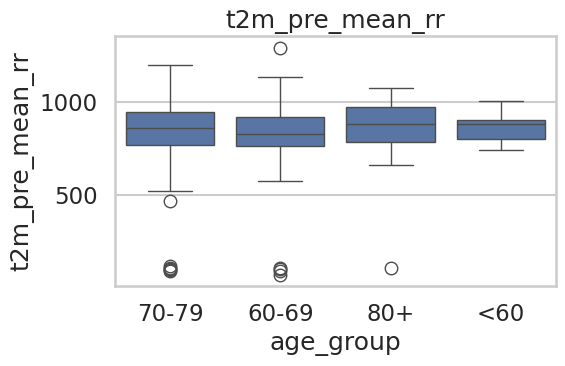

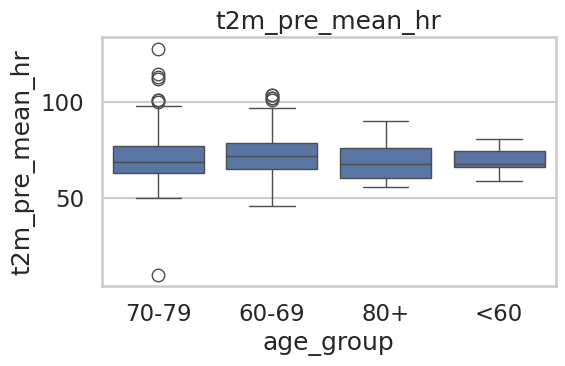

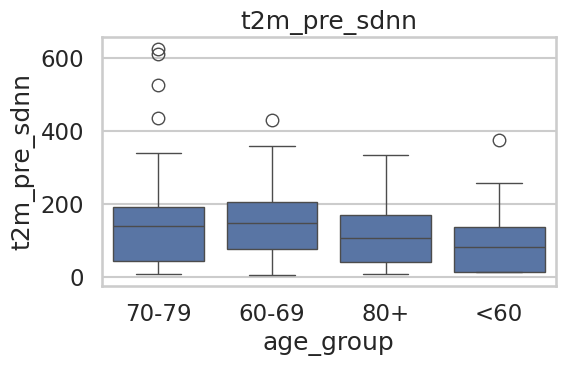

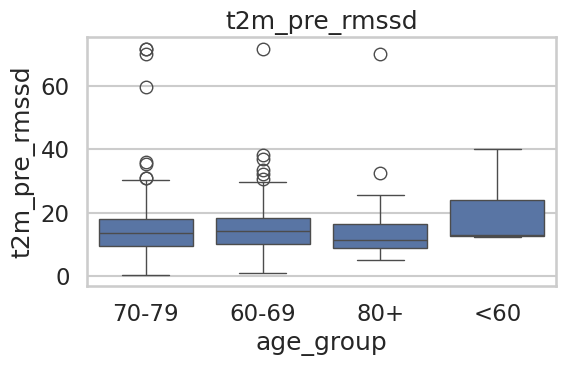

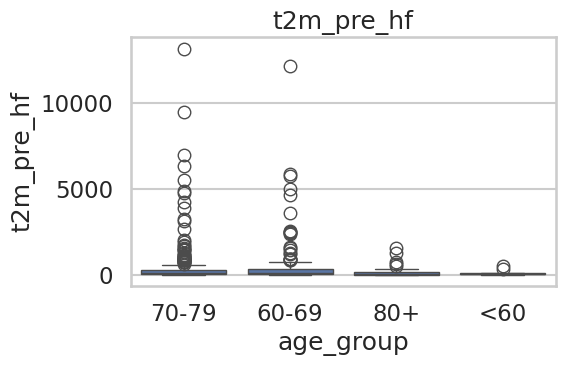

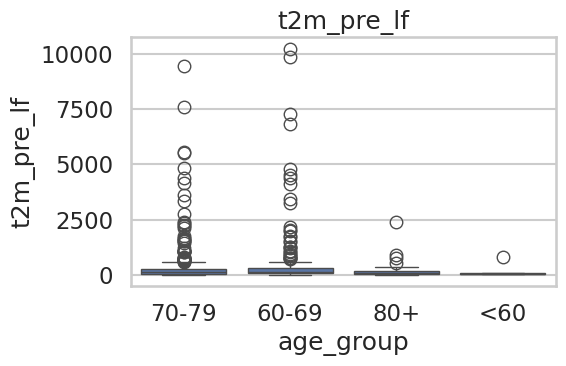

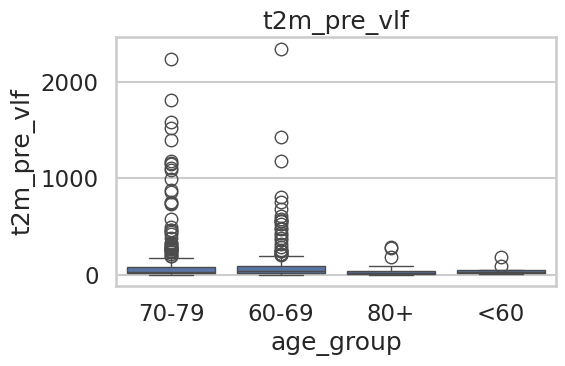

In [11]:
for col in hrv_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x="age_group",
        y=col,
        data=df
    )
    
    plt.title(col)
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_age_group.png", dpi=300)
    
    plt.show()

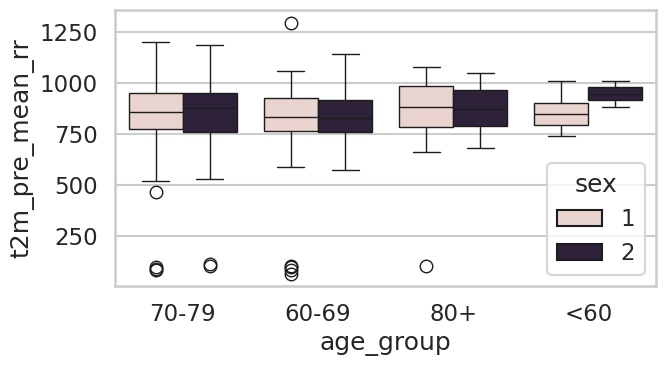

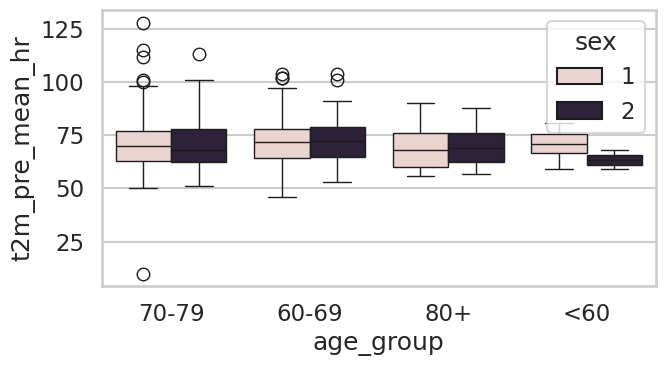

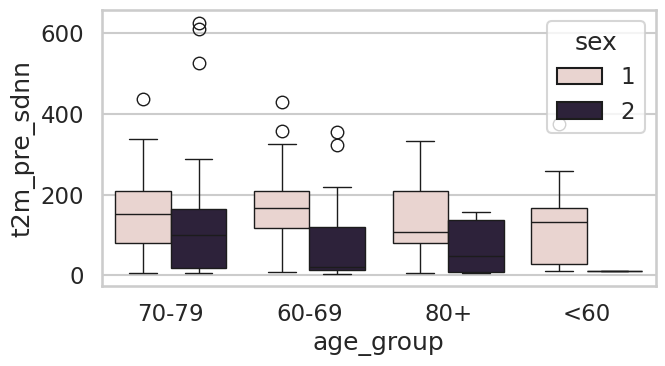

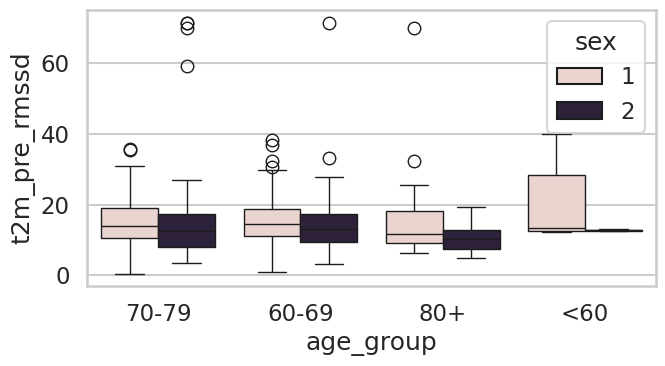

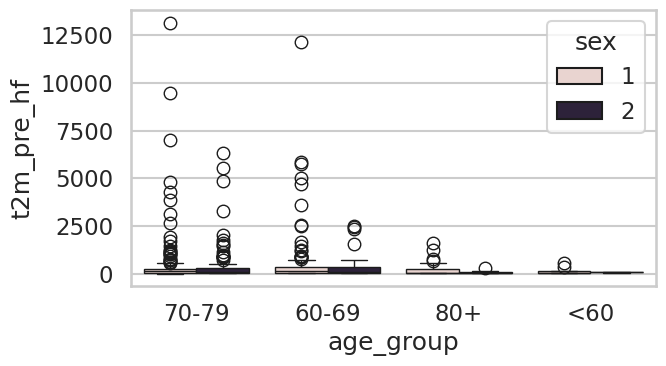

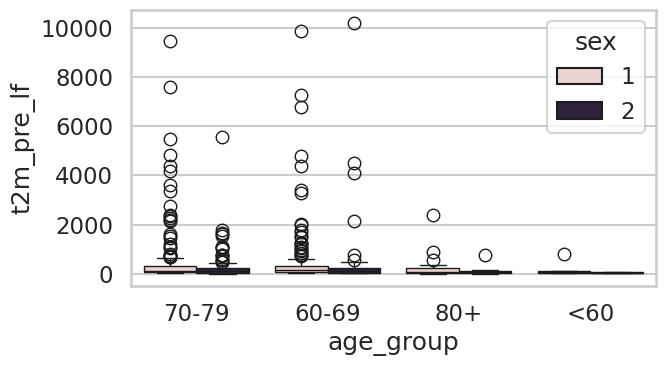

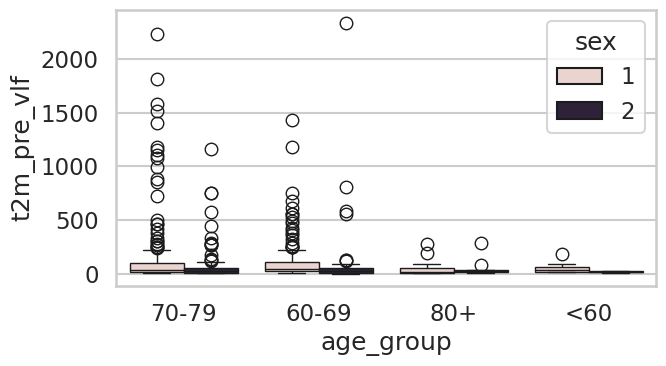

In [12]:
for col in hrv_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.boxplot(
        x="age_group",
        y=col,
        hue="sex",
        data=df
    )
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_age_group_sex.png", dpi=300)
    
    plt.show()

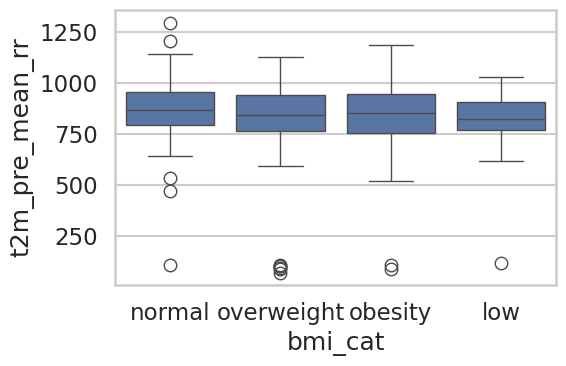

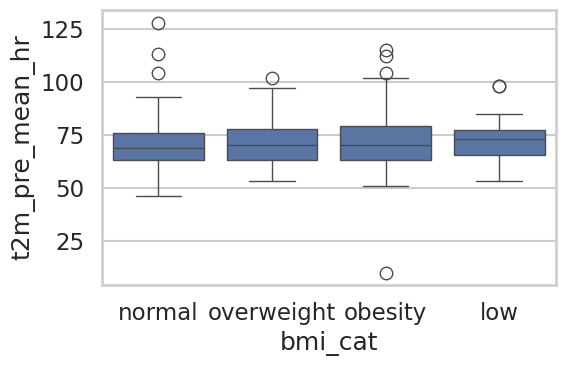

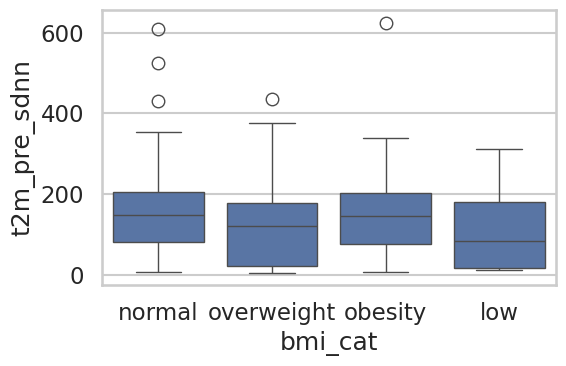

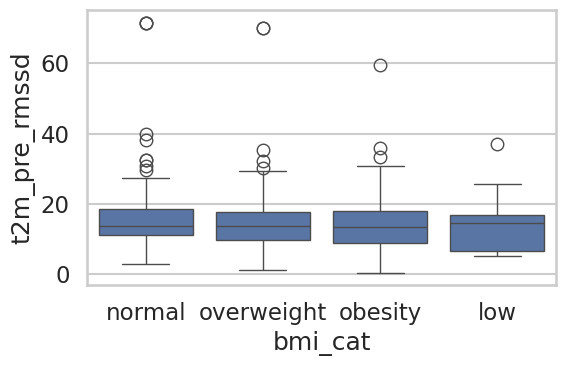

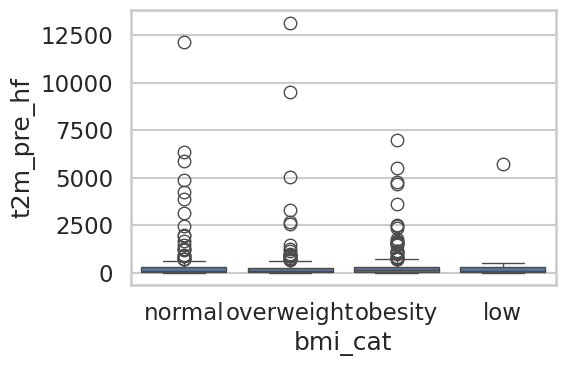

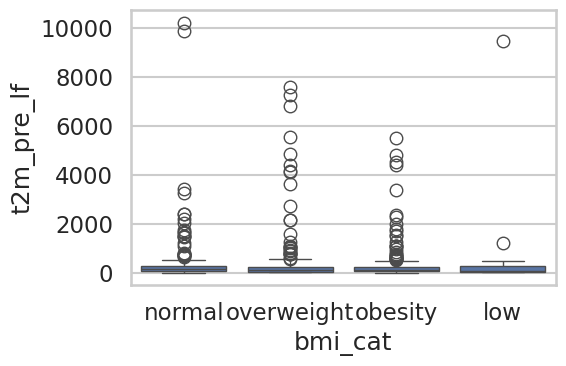

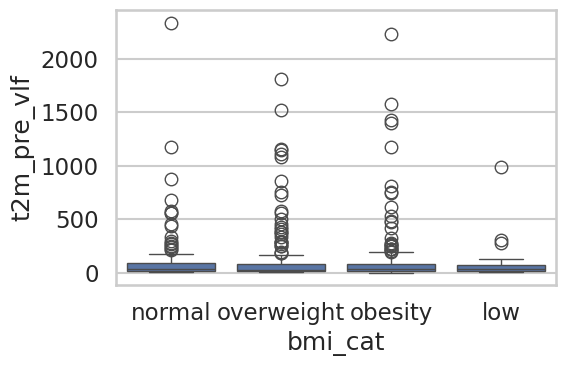

In [13]:
for col in hrv_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x="bmi_cat",
        y=col,
        data=df
    )
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_bmi.png", dpi=300)
    
    plt.show()

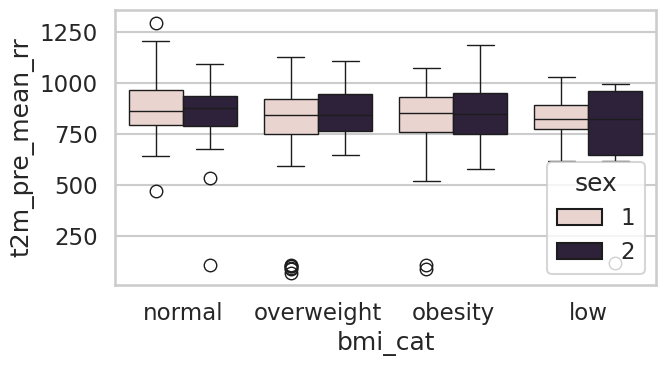

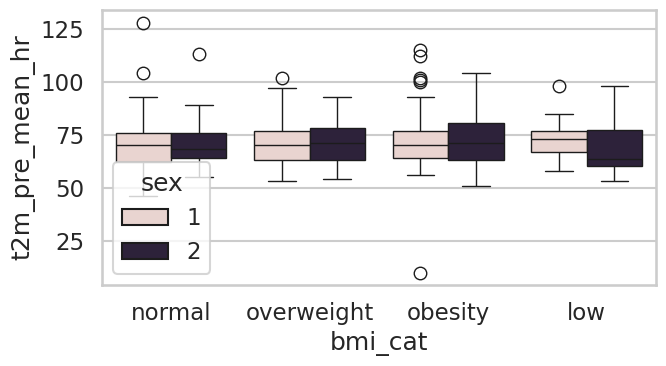

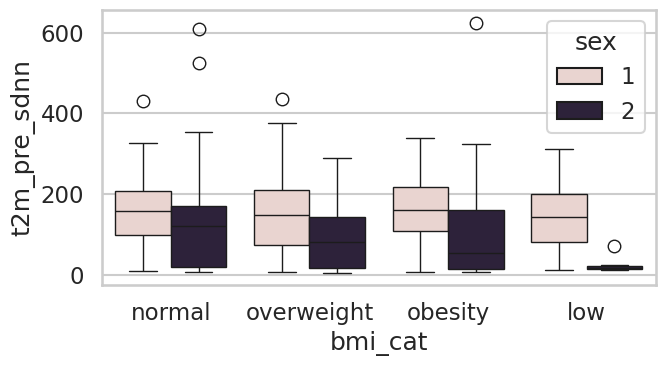

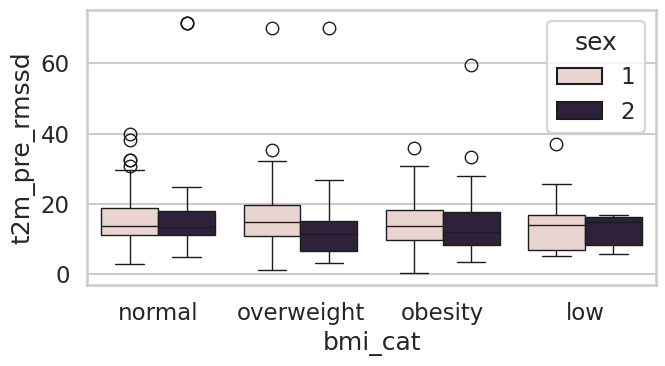

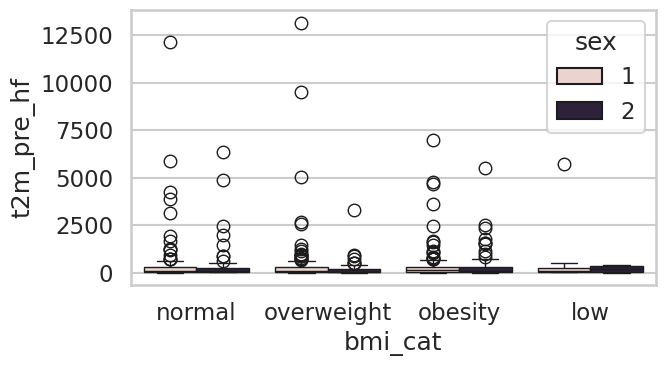

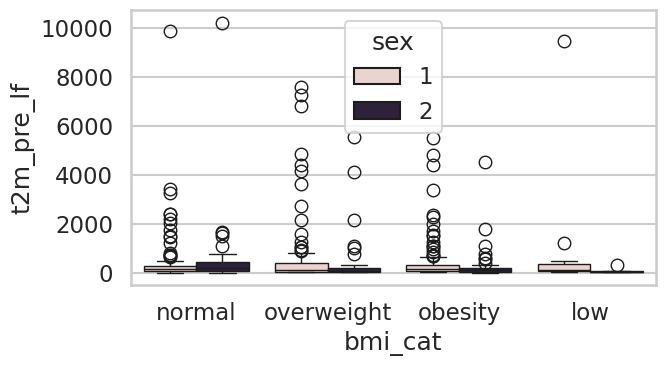

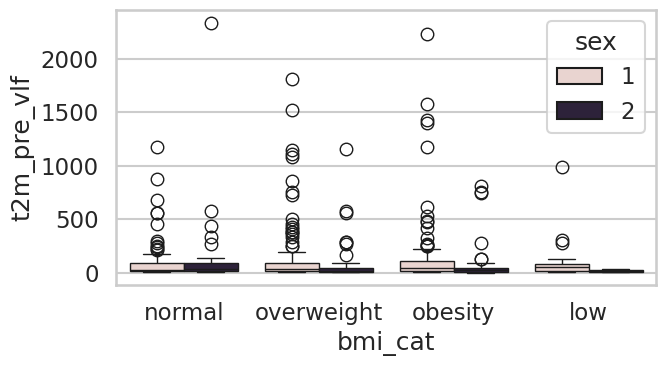

In [15]:
for col in hrv_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.boxplot(
        x="bmi_cat",
        y=col,
        hue="sex",
        data=df
    )
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_bmi_sex.png", dpi=300)
    
    plt.show()

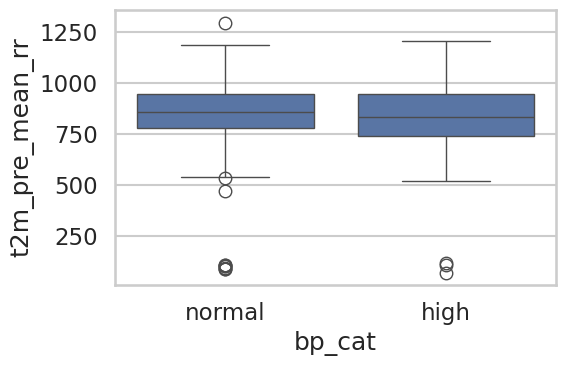

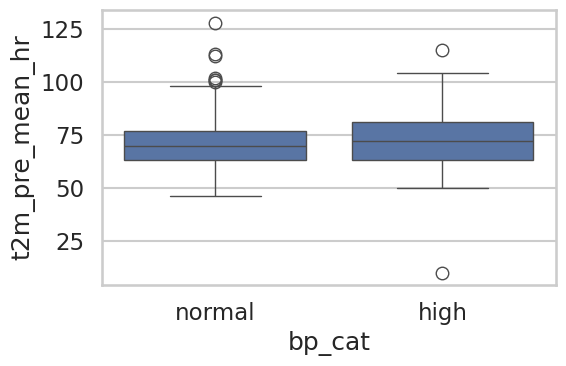

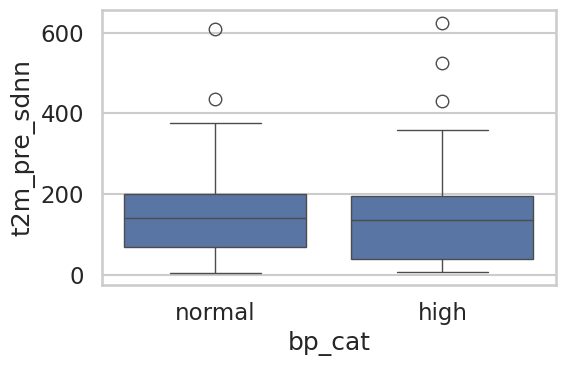

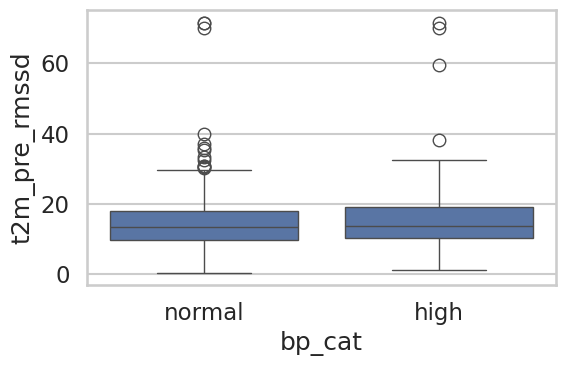

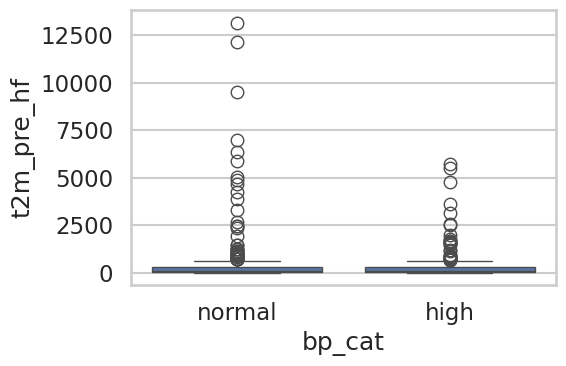

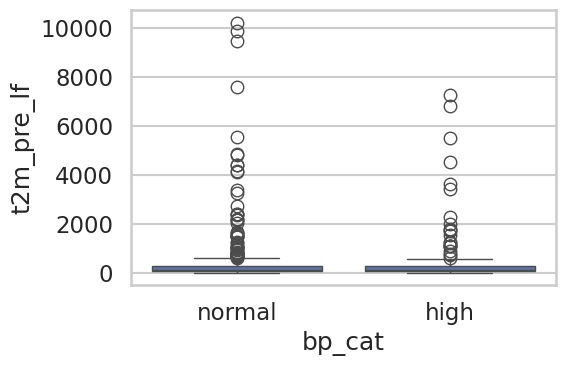

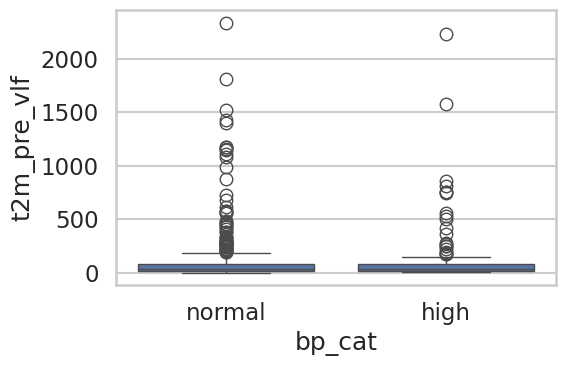

In [16]:
for col in hrv_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x="bp_cat",
        y=col,
        data=df
    )
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_bp.png", dpi=300)
    
    plt.show()

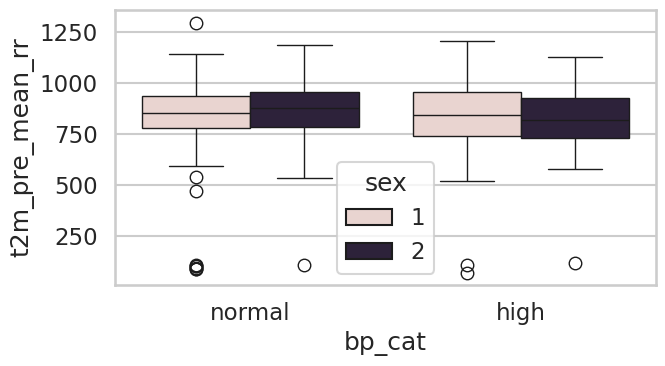

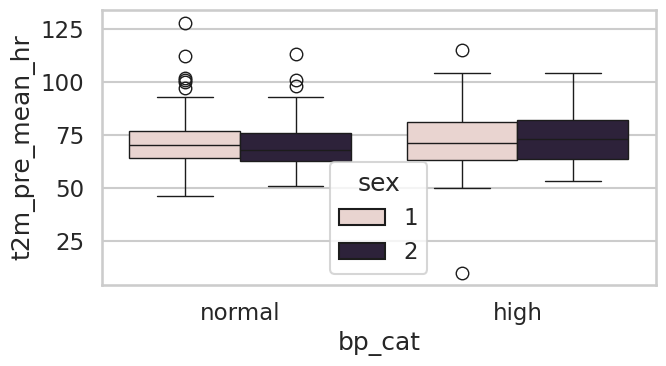

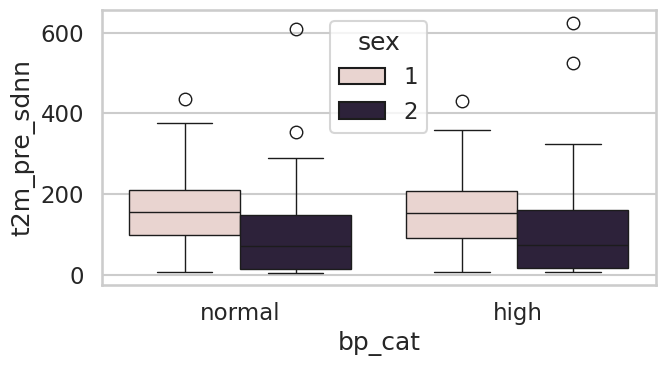

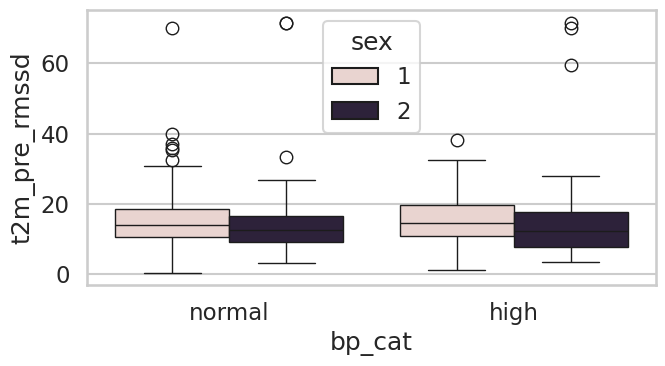

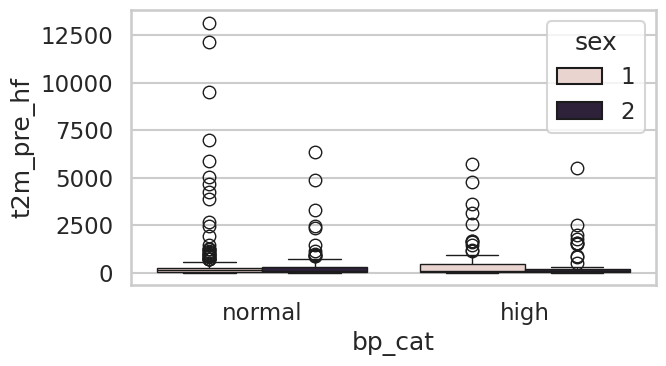

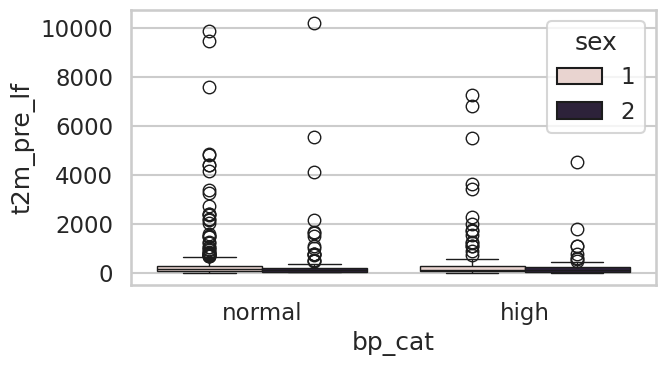

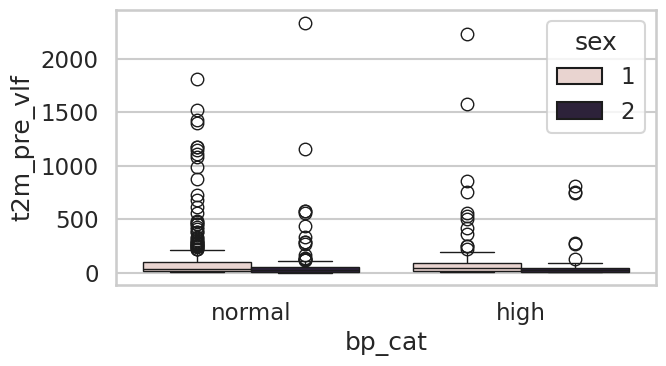

In [17]:
for col in hrv_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.boxplot(
        x="bp_cat",
        y=col,
        hue="sex",
        data=df
    )
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_bp_sex.png", dpi=300)
    
    plt.show()

In [18]:
group_cols = ["age_group", "bmi_cat", "bp_cat"]

for g in group_cols:
    
    table = df.groupby(g)[hrv_cols].median()
    
    print("\n", g)
    print(table)
    
    table.to_csv(TABLE_DIR / f"median_{g}.csv")


 age_group
           t2m_pre_mean_rr  t2m_pre_mean_hr  t2m_pre_sdnn  t2m_pre_rmssd  \
age_group                                                                  
60-69                830.0             72.0         148.0          14.20   
70-79                862.0             69.0         138.0          13.50   
80+                  884.5             68.0         106.0          11.45   
<60                  883.0             68.0          82.0          13.00   

           t2m_pre_hf  t2m_pre_lf  t2m_pre_vlf  
age_group                                       
60-69           128.0       149.0         39.0  
70-79            97.0       111.0         30.0  
80+              50.0        73.0         21.5  
<60              47.0        53.5         31.0  

 bmi_cat
            t2m_pre_mean_rr  t2m_pre_mean_hr  t2m_pre_sdnn  t2m_pre_rmssd  \
bmi_cat                                                                     
low                   823.0             73.0          83.0          14.70

In [19]:
for g in ["age_group", "bmi_cat", "bp_cat"]:
    
    table = df.groupby([g, "sex"])[hrv_cols].median()
    
    print("\n", g)
    print(table)
    
    table.to_csv(TABLE_DIR / f"median_{g}_sex.csv")


 age_group
               t2m_pre_mean_rr  t2m_pre_mean_hr  t2m_pre_sdnn  t2m_pre_rmssd  \
age_group sex                                                                  
60-69     1              833.5             72.0        166.00          14.50   
          2              828.0             72.5         20.80          13.10   
70-79     1              857.0             70.0        152.00          13.95   
          2              876.5             68.0         99.00          12.50   
80+       1              885.0             68.0        107.00          11.60   
          2              871.0             69.0         47.25          10.20   
<60       1              848.5             71.0        131.50          13.50   
          2              946.5             63.5         11.60          12.75   

               t2m_pre_hf  t2m_pre_lf  t2m_pre_vlf  
age_group sex                                       
60-69     1         136.0       158.0         43.0  
          2          79.0   

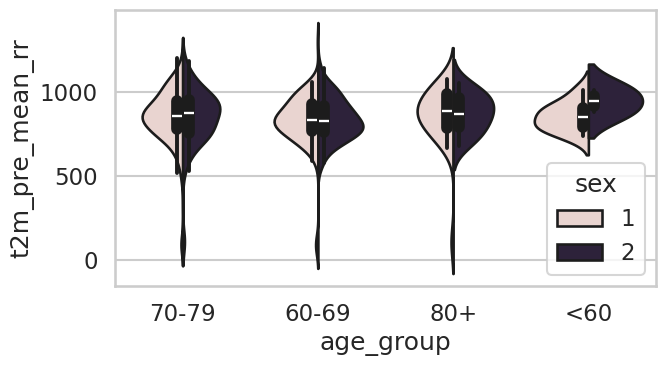

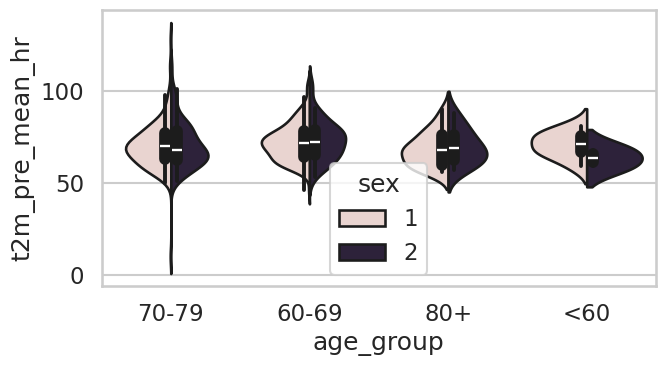

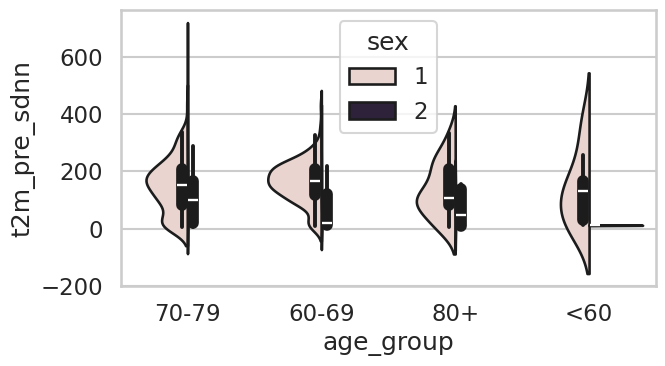

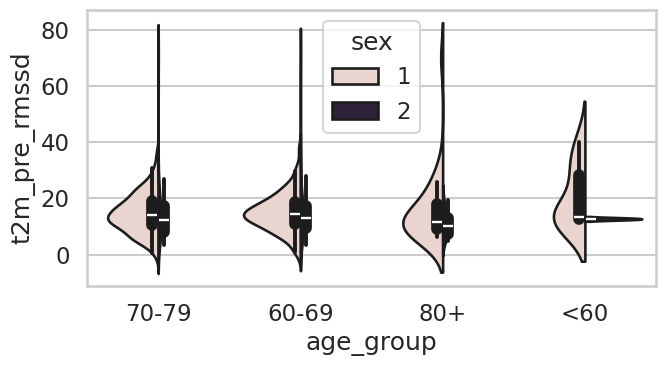

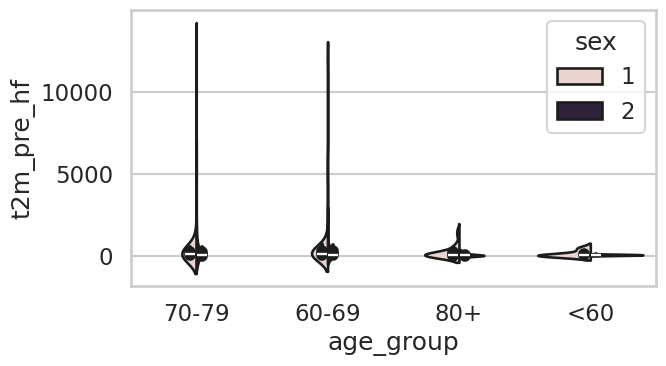

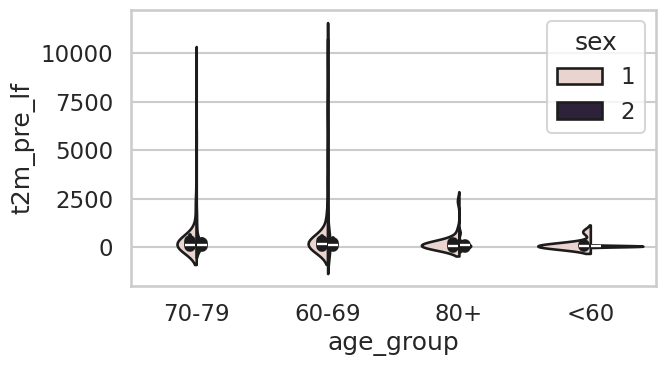

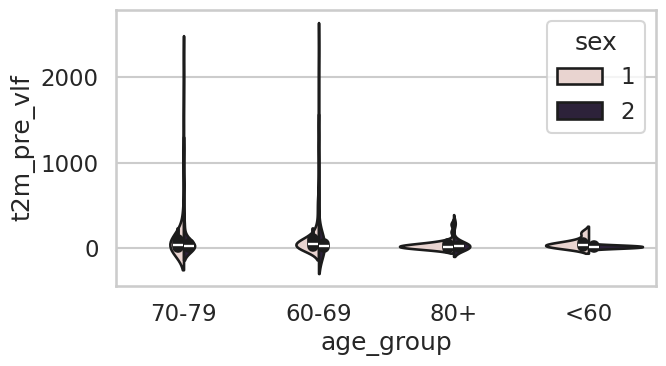

In [20]:
for col in hrv_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.violinplot(
        x="age_group",
        y=col,
        hue="sex",
        data=df,
        split=True
    )
    
    plt.tight_layout()
    
    plt.savefig(FIG_DIR / f"{col}_violin_age_sex.png", dpi=300)
    
    plt.show()

In [21]:
df.to_csv(DATA_DIR / "basal_v2_clean_with_categories.csv", index=False)